# 1. Environment Setup
Sets up the Apache Spark environment and imports the required PySpark libraries and modules. The Spark session is also initialised and Google Drive is mounted to provide access to the dataset.

In [3]:
# Install PySpark
!pip install pyspark

# Import SparkSession
from pyspark.sql import SparkSession

# Create Spark session
spark = SparkSession.builder \
    .appName("Spotify K-Means Clustering") \
    .getOrCreate()

print("Spark version:", spark.version)

Spark version: 4.0.3


In [4]:
# Mount Google Drive
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


# 2. Data Loading and Preprocessing
Loads the Spotify dataset into a Spark DataFrame, checks the dataset structure and data quality, and selects the five audio features used for clustering. The selected features are then assembled into feature vectors and standardised.

In [6]:
# Load Dataset
file_path = '/content/drive/MyDrive/Colab Notebooks/tracks_features_3m.csv'

df = spark.read \
    .option("header", True) \
    .option("inferSchema", True) \
    .option("quote", '"') \
    .option("escape", '"') \
    .option("multiLine", True) \
    .csv(file_path)

print("Number of rows:", df.count())

df.printSchema()

print("Column names:", df.columns)

df.show(5, truncate=False)

Number of rows: 3612075
root
 |-- id: string (nullable = true)
 |-- name: string (nullable = true)
 |-- album: string (nullable = true)
 |-- album_id: string (nullable = true)
 |-- artists: string (nullable = true)
 |-- artist_ids: string (nullable = true)
 |-- track_number: integer (nullable = true)
 |-- disc_number: integer (nullable = true)
 |-- explicit: boolean (nullable = true)
 |-- danceability: double (nullable = true)
 |-- energy: double (nullable = true)
 |-- key: integer (nullable = true)
 |-- loudness: double (nullable = true)
 |-- mode: integer (nullable = true)
 |-- speechiness: double (nullable = true)
 |-- acousticness: double (nullable = true)
 |-- instrumentalness: double (nullable = true)
 |-- liveness: double (nullable = true)
 |-- valence: double (nullable = true)
 |-- tempo: double (nullable = true)
 |-- duration_ms: integer (nullable = true)
 |-- time_signature: double (nullable = true)
 |-- year: integer (nullable = true)
 |-- release_date: timestamp (nullable =

In [7]:
# Define Features for K-Means
features = [
    "danceability",
    "energy",
    "acousticness",
    "valence",
    "tempo"
]

print("Selected K-Means features:", features)

Selected K-Means features: ['danceability', 'energy', 'acousticness', 'valence', 'tempo']


In [8]:
# Exploratory Summary of Selected Features
df.select(features).summary().show()

+-------+-------------------+-------------------+------------------+-------------------+------------------+
|summary|       danceability|             energy|      acousticness|            valence|             tempo|
+-------+-------------------+-------------------+------------------+-------------------+------------------+
|  count|            3612075|            3612075|           3612075|            3612075|           3612075|
|   mean|0.49305652179151166| 0.5095362861749541|0.4467510981968612|0.42798662251857383|117.63435180997693|
| stddev| 0.1896693503477362|0.29468383136917253|0.3852013121583346|0.27048447854587016|30.937038096216266|
|    min|                0.0|                0.0|               0.0|                0.0|               0.0|
|    25%|              0.356|              0.252|            0.0376|              0.191|            94.054|
|    50%|              0.501|              0.524|             0.389| 0.4029999999999999|           116.724|
|    75%|              0.633

In [9]:
# Check for Missing Values
from pyspark.sql import functions as F

df.select([
    F.count(
        F.when(F.col(c).isNull(), c)
    ).alias(c)
    for c in features
]).show()

+------------+------+------------+-------+-----+
|danceability|energy|acousticness|valence|tempo|
+------------+------+------------+-------+-----+
|           0|     0|           0|      0|    0|
+------------+------+------------+-------+-----+



In [23]:
# Check Zero-Tempo Records
zero_tempo_count = df.filter(F.col("tempo") == 0).count()

print("Number of records with tempo = 0:", zero_tempo_count)

Number of records with tempo = 0: 8331


In [24]:
# Check Duplicate Feature Combinations
df.groupBy(features) \
    .count() \
    .groupBy("count") \
    .count() \
    .orderBy("count") \
    .show()

+-----+-------+
|count|  count|
+-----+-------+
|    3|1163860|
|    6|  15014|
|    9|   1685|
|   12|    474|
|   15|    123|
|   18|     81|
|   21|     50|
|   24|     25|
|   27|     12|
|   30|     22|
|   33|     10|
|   36|      7|
|   39|      5|
|   42|      7|
|   45|      4|
|   48|      4|
|   51|      3|
|   54|      5|
|   57|      3|
|   63|      1|
+-----+-------+
only showing top 20 rows


In [10]:
# Select Required Columns
kmeans_df = df.select(
    "id",
    "name",
    "artists",
    "danceability",
    "energy",
    "acousticness",
    "valence",
    "tempo"
)

kmeans_df.printSchema()

root
 |-- id: string (nullable = true)
 |-- name: string (nullable = true)
 |-- artists: string (nullable = true)
 |-- danceability: double (nullable = true)
 |-- energy: double (nullable = true)
 |-- acousticness: double (nullable = true)
 |-- valence: double (nullable = true)
 |-- tempo: double (nullable = true)



In [11]:
# Feature Vectorisation: Assemble Features into a Vector
from pyspark.ml.feature import VectorAssembler

assembler = VectorAssembler(
    inputCols=features,
    outputCol="raw_features"
)

assembled_df = assembler.transform(kmeans_df)

assembled_df.select(
    "id",
    "name",
    "raw_features"
).show(5, truncate=False)

+----------------------+---------------------+-----------------------------------+
|id                    |name                 |raw_features                       |
+----------------------+---------------------+-----------------------------------+
|7lmeHLHBe4nmXzuXc0HDjk|Testify              |[0.47,0.978,0.0261,0.503,117.906]  |
|1wsRitfRRtWyEapl0q22o8|Guerrilla Radio      |[0.599,0.957,0.0129,0.489,103.68]  |
|1hR0fIFK2qRG3f3RF70pb7|Calm Like a Bomb     |[0.315,0.97,0.0234,0.37,149.749]   |
|2lbASgTSoDO7MTuLAXlTW0|Mic Check            |[0.44,0.967,0.163,0.574,96.752]    |
|1MQTmpYOZ6fcMQc56Hdo7T|Sleep Now In the Fire|[0.426,0.929,0.00162,0.539,127.059]|
+----------------------+---------------------+-----------------------------------+
only showing top 5 rows


In [12]:
# Feature Scaling: Standardise Features
from pyspark.ml.feature import StandardScaler

scaler = StandardScaler(
    inputCol="raw_features",
    outputCol="scaled_features",
    withStd=True,
    withMean=True
)

scaler_model = scaler.fit(assembled_df)

scaled_df = scaler_model.transform(assembled_df)

scaled_df.select(
    "id",
    "name",
    "raw_features",
    "scaled_features"
).show(5, truncate=False)

+----------------------+---------------------+-----------------------------------+------------------------------------------------------------------------------------------------------+
|id                    |name                 |raw_features                       |scaled_features                                                                                       |
+----------------------+---------------------+-----------------------------------+------------------------------------------------------------------------------------------------------+
|7lmeHLHBe4nmXzuXc0HDjk|Testify              |[0.47,0.978,0.0261,0.503,117.906]  |[-0.12156166375448794,1.5897163805984698,-1.0920292452790192,0.27732969331426616,0.008780678653908962]|
|1wsRitfRRtWyEapl0q22o8|Guerrilla Radio      |[0.599,0.957,0.0129,0.489,103.68]  |[0.5585693102984808,1.518453563421062,-1.1262970413206237,0.22557071595902392,-0.45105648984803837]   |
|1hR0fIFK2qRG3f3RF70pb7|Calm Like a Bomb     |[0.315,0.97,0.0234,0.37,

# 3. K-Means Model Development and Analysis
Develops the K-Means clustering model using Spark MLlib. Different values of K are evaluated using the Silhouette Score, with the best-performing K selected for the final model. The final model is then trained on the full dataset, and the resulting clusters are evaluated and profiled based on their audio characteristics.

In [13]:
# Create Sample for K Selection
sample_df = scaled_df.sample(
    withReplacement=False,
    fraction=0.10,
    seed=42
)

print("Sample size:", sample_df.count())

sample_df.select("scaled_features").show(5, truncate=False)

Sample size: 361469
+----------------------------------------------------------------------------------------------------+
|scaled_features                                                                                     |
+----------------------------------------------------------------------------------------------------+
|[-1.1391219582678447,1.2334022947114316,-1.141769470442439,0.7024927215894696,1.7847102239817572]   |
|[-0.3957229866285528,1.0060399732406544,-1.1514786793208938,0.07029378389329752,1.5052393847530339] |
|[-0.43262931855390774,1.0637289204795084,-1.1515825211270805,0.5361245800904768,1.7017352477730898] |
|[1.0647132909890622,-0.6703329641707447,0.8988777838351081,-0.20698645193835657,0.25188733859367746]|
|[0.49002897957996455,0.7888580542237932,-1.1000769852584869,1.9964671554705238,1.6929431973138944]  |
+----------------------------------------------------------------------------------------------------+
only showing top 5 rows


In [14]:
# Evaluate Candidate K Values Using Silhouette Score
from pyspark.ml.clustering import KMeans
from pyspark.ml.evaluation import ClusteringEvaluator

k_values = range(2, 9)

evaluator = ClusteringEvaluator(
    featuresCol="scaled_features",
    predictionCol="prediction",
    metricName="silhouette",
    distanceMeasure="squaredEuclidean"
)

silhouette_scores = []

for k in k_values:

    print(f"Training K-Means with K = {k}...")

    kmeans = KMeans(
        featuresCol="scaled_features",
        predictionCol="prediction",
        k=k,
        seed=42
    )

    model = kmeans.fit(sample_df)

    predictions = model.transform(sample_df)

    silhouette = evaluator.evaluate(predictions)

    silhouette_scores.append((k, silhouette))

    print(f"Silhouette Score: {silhouette:.4f}")

Training K-Means with K = 2...
Silhouette Score: 0.5070
Training K-Means with K = 3...
Silhouette Score: 0.4271
Training K-Means with K = 4...
Silhouette Score: 0.3817
Training K-Means with K = 5...
Silhouette Score: 0.3752
Training K-Means with K = 6...
Silhouette Score: 0.3720
Training K-Means with K = 7...
Silhouette Score: 0.3527
Training K-Means with K = 8...
Silhouette Score: 0.3437


In [15]:
# Inspect Cluster Centres
kmeans_2 = KMeans(
    featuresCol="scaled_features",
    predictionCol="prediction",
    k=2,
    seed=42
)

model_2 = kmeans_2.fit(sample_df)

centers = model_2.clusterCenters()

for i, center in enumerate(centers):
    print(f"Cluster {i}: {center}")

Cluster 0: [ 0.36337399  0.64865039 -0.64438029  0.40620928  0.23665342]
Cluster 1: [-0.55737276 -0.99053798  0.98844969 -0.62304877 -0.36157553]


In [17]:
# Train Final K-Means Model on Full Dataset
final_kmeans = KMeans(
    featuresCol="scaled_features",
    predictionCol="prediction",
    k=2,
    seed=42
)

final_model = final_kmeans.fit(scaled_df)

In [18]:
# Assign Tracks to Clusters
predictions_df = final_model.transform(scaled_df)

predictions_df.select(
    "id",
    "name",
    "artists",
    "danceability",
    "energy",
    "acousticness",
    "valence",
    "tempo",
    "prediction"
).show(10, truncate=False)

+----------------------+----------------------+----------------------------+------------------+------+-----------------+------------------+------------------+----------+
|id                    |name                  |artists                     |danceability      |energy|acousticness     |valence           |tempo             |prediction|
+----------------------+----------------------+----------------------------+------------------+------+-----------------+------------------+------------------+----------+
|7lmeHLHBe4nmXzuXc0HDjk|Testify               |['Rage Against The Machine']|0.47              |0.978 |0.0261           |0.503             |117.906           |0         |
|1wsRitfRRtWyEapl0q22o8|Guerrilla Radio       |['Rage Against The Machine']|0.599             |0.957 |0.0129           |0.489             |103.68            |0         |
|1hR0fIFK2qRG3f3RF70pb7|Calm Like a Bomb      |['Rage Against The Machine']|0.315             |0.97  |0.0234           |0.37              |149.749    

In [19]:
# Analyse Cluster Distribution
predictions_df.groupBy("prediction") \
    .count() \
    .orderBy("prediction") \
    .show()

+----------+-------+
|prediction|  count|
+----------+-------+
|         0|2183496|
|         1|1428579|
+----------+-------+



In [20]:
# Calculate Average Feature Values by Cluster
cluster_profiles = predictions_df.groupBy("prediction").agg(
    F.count("*").alias("track_count"),
    F.avg("danceability").alias("avg_danceability"),
    F.avg("energy").alias("avg_energy"),
    F.avg("acousticness").alias("avg_acousticness"),
    F.avg("valence").alias("avg_valence"),
    F.avg("tempo").alias("avg_tempo")
).orderBy("prediction")

cluster_profiles.show(truncate=False)

+----------+-----------+------------------+-------------------+-------------------+------------------+-----------------+
|prediction|track_count|avg_danceability  |avg_energy         |avg_acousticness   |avg_valence       |avg_tempo        |
+----------+-----------+------------------+-------------------+-------------------+------------------+-----------------+
|0         |2183496    |0.5623962573780866|0.7001742446916185 |0.19868868232597514|0.5386692767452097|124.8992820197488|
|1         |1428579    |0.3870749587877354|0.21815777657255442|0.8258993936735971 |0.258814926187552 |106.530348423856 |
+----------+-----------+------------------+-------------------+-------------------+------------------+-----------------+



In [21]:
# Evaluate Final Model Using Silhouette Score
final_silhouette = evaluator.evaluate(predictions_df)

print(f"Final silhouette score: {final_silhouette:.4f}")

Final silhouette score: 0.5067


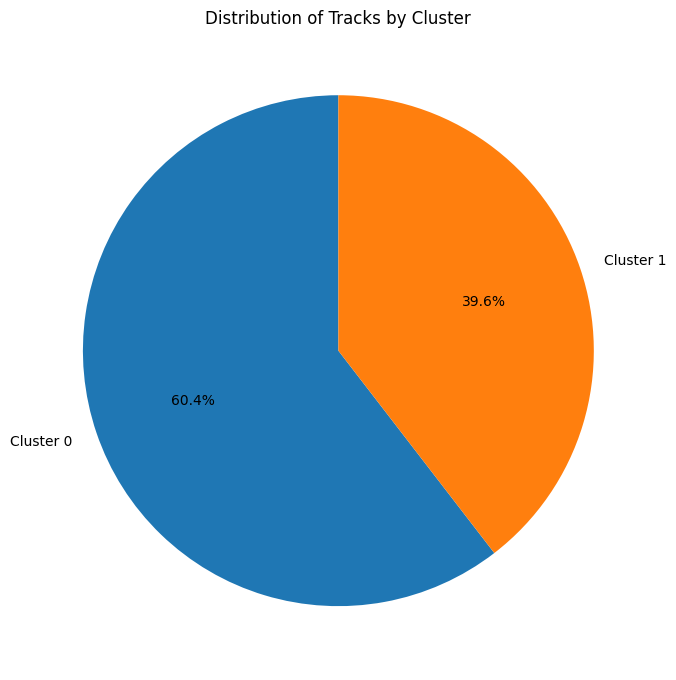

In [22]:
import matplotlib.pyplot as plt

# Cluster counts from PySpark
cluster_counts = (
    predictions_df
    .groupBy("prediction")
    .count()
    .orderBy("prediction")
    .toPandas()
)

# Pie chart
plt.figure(figsize=(7, 7))

plt.pie(
    cluster_counts["count"],
    labels=[f"Cluster {c}" for c in cluster_counts["prediction"]],
    autopct='%1.1f%%',
    startangle=90
)

plt.title("Distribution of Tracks by Cluster")

plt.tight_layout()
plt.show()

# 4. Spark SQL Analysis
Uses Spark SQL to analyse the clustered dataset through SQL queries. Cluster-level statistics such as track counts, average feature values, and feature ranges are calculated to further interpret the characteristics of each cluster.

In [27]:
# Register Clustered Dataset as a Temporary SQL View
predictions_df.createOrReplaceTempView("spotify_tracks")

In [ ]:
# Analyse Cluster Profiles Using Spark SQL
cluster_summary = spark.sql("""
    SELECT
        prediction AS cluster,
        COUNT(*) AS track_count,

        ROUND(AVG(danceability), 3) AS avg_danceability,
        ROUND(MIN(danceability), 3) AS min_danceability,
        ROUND(MAX(danceability), 3) AS max_danceability,

        ROUND(AVG(energy), 3) AS avg_energy,
        ROUND(MIN(energy), 3) AS min_energy,
        ROUND(MAX(energy), 3) AS max_energy,

        ROUND(AVG(acousticness), 3) AS avg_acousticness,
        ROUND(MIN(acousticness), 3) AS min_acousticness,
        ROUND(MAX(acousticness), 3) AS max_acousticness,

        ROUND(AVG(valence), 3) AS avg_valence,
        ROUND(MIN(valence), 3) AS min_valence,
        ROUND(MAX(valence), 3) AS max_valence,

        ROUND(AVG(tempo), 3) AS avg_tempo,
        ROUND(MIN(tempo), 3) AS min_tempo,
        ROUND(MAX(tempo), 3) AS max_tempo

    FROM spotify_tracks
    GROUP BY prediction
    ORDER BY prediction
""")

cluster_summary.show(truncate=False)

+-------+-----------+----------------+----------------+----------------+----------+----------+----------+----------------+----------------+----------------+-----------+-----------+-----------+---------+---------+---------+
|cluster|track_count|avg_danceability|min_danceability|max_danceability|avg_energy|min_energy|max_energy|avg_acousticness|min_acousticness|max_acousticness|avg_valence|min_valence|max_valence|avg_tempo|min_tempo|max_tempo|
+-------+-----------+----------------+----------------+----------------+----------+----------+----------+----------------+----------------+----------------+-----------+-----------+-----------+---------+---------+---------+
|0      |2183496    |0.562           |0.034           |1.0             |0.7       |0.0       |1.0       |0.199           |0.0             |0.996           |0.539      |0.0        |1.0        |124.899  |30.133   |248.934  |
|1      |1428579    |0.387           |0.0             |0.987           |0.218     |0.0       |1.0       |0.8

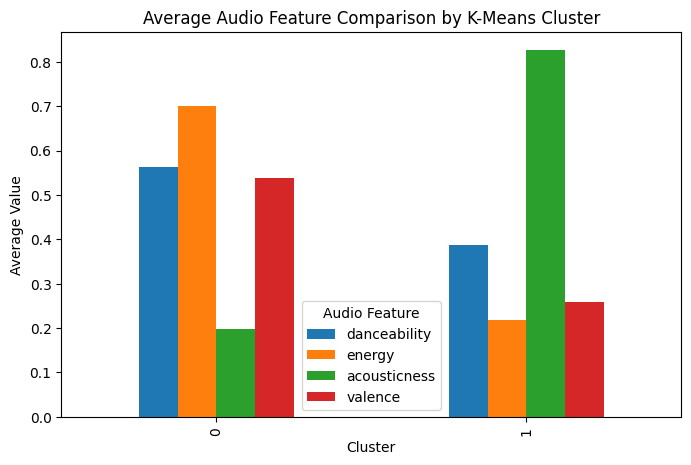

In [29]:
import pandas as pd
import matplotlib.pyplot as plt

summary_df = spark.sql("""
SELECT
    prediction AS cluster,
    ROUND(AVG(danceability),3) AS danceability,
    ROUND(AVG(energy),3) AS energy,
    ROUND(AVG(acousticness),3) AS acousticness,
    ROUND(AVG(valence),3) AS valence
FROM spotify_tracks
GROUP BY prediction
ORDER BY prediction
""").toPandas()

summary_df.set_index("cluster").plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Average Audio Feature Comparison by K-Means Cluster")
plt.ylabel("Average Value")
plt.xlabel("Cluster")
plt.legend(title="Audio Feature")
plt.show()

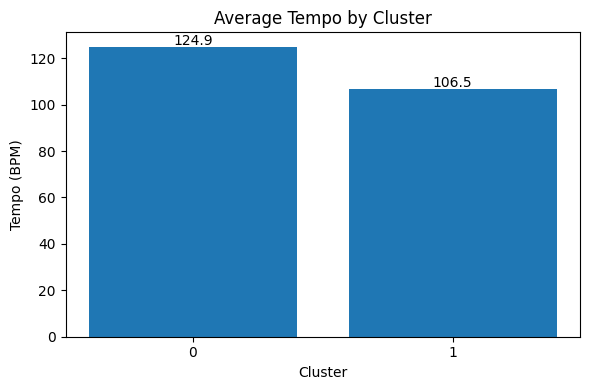

In [28]:
import matplotlib.pyplot as plt

# Get average tempo per cluster
tempo_df = spark.sql("""
SELECT
    prediction AS cluster,
    ROUND(AVG(tempo),3) AS avg_tempo
FROM spotify_tracks
GROUP BY prediction
ORDER BY prediction
""").toPandas()

# Create chart
plt.figure(figsize=(6,4))

plt.bar(
    tempo_df["cluster"].astype(str),
    tempo_df["avg_tempo"]
)

plt.title("Average Tempo by Cluster")
plt.xlabel("Cluster")
plt.ylabel("Tempo (BPM)")

# Add values above bars
for i, v in enumerate(tempo_df["avg_tempo"]):
    plt.text(i, v + 1, f"{v:.1f}", ha="center")

plt.tight_layout()
plt.show()

# 5. Performance Evaluation
Measures the execution time of key stages of the Spark implementation, including data loading, feature preprocessing, K-Means training, and cluster prediction. These performance results are later used to compare the Spark implementation with the Pandas/Scikit-learn implementation.

In [ ]:
# Measure Data Loading Time
import time

start_time = time.time()

benchmark_df = spark.read.csv(
    file_path,
    header=True,
    inferSchema=True
)

row_count = benchmark_df.count()

loading_time = time.time() - start_time

print(f"Rows loaded: {row_count}")
print(f"Spark data loading time: {loading_time:.2f} seconds")
print(f"Spark data loading time: {loading_time / 60:.2f} minutes")

Rows loaded: 3612075
Spark data loading time: 31.84 seconds
Spark data loading time: 0.53 minutes


In [ ]:
# Measure Feature Preprocessing Time: VectorAssembler & StandardScaler

start_time = time.time()

benchmark_assembler = VectorAssembler(
    inputCols=features,
    outputCol="benchmark_raw_features"
)

benchmark_assembled = benchmark_assembler.transform(kmeans_df)

benchmark_scaler = StandardScaler(
    inputCol="benchmark_raw_features",
    outputCol="benchmark_scaled_features",
    withStd=True,
    withMean=True
)

benchmark_scaler_model = benchmark_scaler.fit(benchmark_assembled)

benchmark_scaled = benchmark_scaler_model.transform(benchmark_assembled)

# Force Spark to execute the transformations
benchmark_scaled.select("benchmark_scaled_features").count()

preprocessing_time = time.time() - start_time

print(f"Spark preprocessing time: {preprocessing_time:.2f} seconds")
print(f"Spark preprocessing time: {preprocessing_time / 60:.2f} minutes")

Spark preprocessing time: 36.40 seconds
Spark preprocessing time: 0.61 minutes


In [ ]:
# Measure Final K-Means Training Time
start_time = time.time()

benchmark_kmeans = KMeans(
    featuresCol="scaled_features",
    predictionCol="prediction",
    k=2,
    seed=42
)

benchmark_model = benchmark_kmeans.fit(scaled_df)

training_time = time.time() - start_time

print(f"Final K-Means training time: {training_time:.2f} seconds")
print(f"Final K-Means training time: {training_time / 60:.2f} minutes")

Final K-Means training time: 260.87 seconds
Final K-Means training time: 4.35 minutes


In [ ]:
# Measure Cluster Prediction Time
start_time = time.time()

benchmark_predictions = benchmark_model.transform(scaled_df)

# Force Spark to execute the transformation
benchmark_predictions.select("prediction").count()

prediction_time = time.time() - start_time

print(f"Prediction time: {prediction_time:.2f} seconds")
print(f"Prediction time: {prediction_time / 60:.2f} minutes")

Prediction time: 18.54 seconds
Prediction time: 0.31 minutes


# 6. Summary of Results

### **Dataset**
- **Dataset size:** 3,612,075 records
- **Features used:** danceability, energy, acousticness, valence, and tempo

### **Model Selection**
- **Candidate K values:** 2–8
- **Selected K:** 2
- **Sample silhouette score:** 0.5070
- **Full-data silhouette score:** 0.5067

### **Cluster Profiles**
**Cluster 0** was characterised by higher energy, danceability, valence, and tempo, together with lower acousticness. It can therefore be described as an energetic/upbeat cluster.

**Cluster 1** was characterised by substantially higher acousticness and lower energy, danceability, valence, and tempo. It can therefore be described as an acoustic/low-energy cluster.

### **Spark Performance**
The performance of the Spark implementation was measured across four stages: data loading, feature preprocessing, K-Means training, and cluster prediction.

- **Data loading:** 31.84 seconds (0.53 minutes)
- **Feature preprocessing:** 36.40 seconds (0.61 minutes)
- **K-Means training:** 260.87 seconds (4.35 minutes)
- **Cluster prediction:** 18.54 seconds (0.31 minutes)

The total of these independently measured stages is **347.65 seconds (5.79 minutes)**. These measurements will be compared with the corresponding Pandas/Scikit-learn implementation to evaluate the performance and scalability of the two approaches.